### 00. imports

In [1]:
from statistics import median

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

### 01. load and check the dataset

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [3]:
df.head(5)

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [4]:
df.shape

(37249, 2)

In [5]:
df.sample()["clean_comment"].values

<StringArray>
[' ready comply please sakshi maharaj provide wife ']
Length: 1, dtype: str

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   clean_comment  37149 non-null  str  
 1   category       37249 non-null  int64
dtypes: int64(1), str(1)
memory usage: 582.1 KB


### 02. clean the data

In [7]:
df.isnull().sum()

clean_comment    100
category           0
dtype: int64

In [8]:
df[df["clean_comment"].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [9]:
df.dropna(inplace=True)

In [10]:
# check the duplicate
df.duplicated().sum()

np.int64(350)

In [11]:
df[df["clean_comment"].duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [12]:
# remove the duplicates
df.drop_duplicates(inplace=True)

In [13]:
# again check the duplicates
df.duplicated().sum()

np.int64(0)

In [14]:
# check the new line or empty strings
print("before cleaning empty columns : " , (df["clean_comment"].str.strip()=='').sum())
df = df[~(df["clean_comment"].str.strip()=='')]
print("after cleaning empty columns : " , (df["clean_comment"].str.strip()=='').sum())


before cleaning empty columns :  6
after cleaning empty columns :  0


In [15]:
# convert to lowercase
df["clean_comment"] = df["clean_comment"].str.lower()
df.head(5)

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [16]:
# check any string is starting or ending with the empty spacing
print(df['clean_comment'].apply(lambda x: x.startswith(' ') or x.startswith(' ')).sum())

12121


In [17]:
# remove the empty spacing
df["clean_comment"] = df["clean_comment"].str.strip()

df['clean_comment'].apply(lambda x: x.startswith(' ') or x.startswith(' ')).sum()

np.int64(0)

In [18]:
# check any urls in dataset
url_patterns = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
df[df["clean_comment"].str.contains(url_patterns,regex = True)].head()

,clean_comment,category


In [19]:
# check the \n in the mid on the text
df[df["clean_comment"].str.contains("\n",regex = True)].sum()

clean_comment    what missing jpg\nand why this brilliant edit ...
category                                                        67
dtype: object

In [20]:
df["clean_comment"]=df["clean_comment"].str.replace("\n",' ',regex = True)
df[df["clean_comment"].str.contains("\n",regex = True)].sum()

clean_comment     
category         0
dtype: object

### 03. EDA

<Axes: xlabel='category', ylabel='count'>

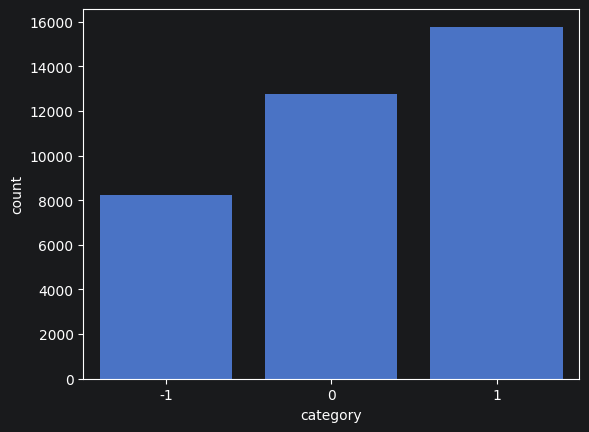

In [21]:
import seaborn as sns
import matplotlib_inline
import matplotlib.pyplot as plt

# plot the category
sns.countplot(data = df , x="category")

this was imbalance dataset

In [22]:
# check the percentage
df.category.value_counts(normalize=True).mul(100).round(2)

category
 1    42.86
 0    34.71
-1    22.42
Name: proportion, dtype: float64

In [23]:
df["word_count"] = df["clean_comment"].apply(lambda x: len(x.split()))
df.head(5)

,clean_comment,category,word_count
0,family mormon have never tried explain them th...,1,39
1,buddhism has very much lot compatible with chr...,1,196
2,seriously don say thing first all they won get...,-1,86
3,what you have learned yours and only yours wha...,0,29
4,for your own benefit you may want read living ...,1,112


In [24]:
df["word_count"].describe()

count    36793.000000
mean        29.667464
std         56.790738
min          1.000000
25%          6.000000
50%         13.000000
75%         30.000000
max       1307.000000
Name: word_count, dtype: float64

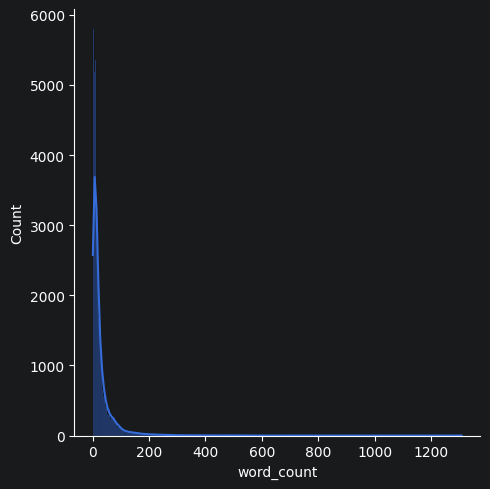

In [25]:
sns.displot(df["word_count"],kde=True)

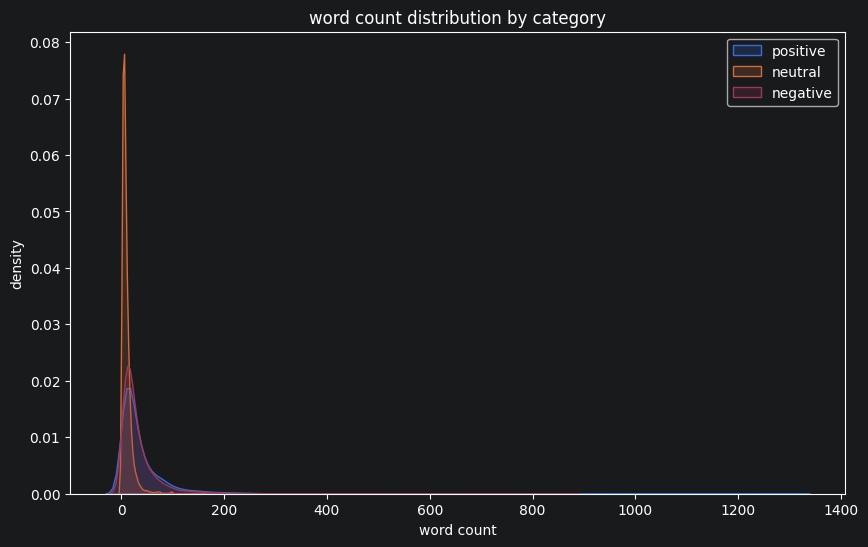

In [26]:
plt.figure(figsize=(10,6))

sns.kdeplot(df[df["category"]==1]["word_count"],label = "positive",fill=True,alpha = 0.2)
sns.kdeplot(df[df["category"]==0]["word_count"],label = "neutral",fill=True,alpha = 0.2)
sns.kdeplot(df[df["category"]==-1]["word_count"],label = "negative",fill=True,alpha = 0.2)

plt.title("word count distribution by category")
plt.xlabel("word count")
plt.ylabel("density")
plt.legend()

plt.show()

<b>Positive comments (category 1):</b> These graph is shows wide speread of positive word count, so this indicates that longer comment s are more common to positive.

<b>Neutral comments (category 0): </b>The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.

<b>Negative comments (category -1):</b> These comments have a distribution somewhat similar to positive comments but with a smaller proportion of longer comments.


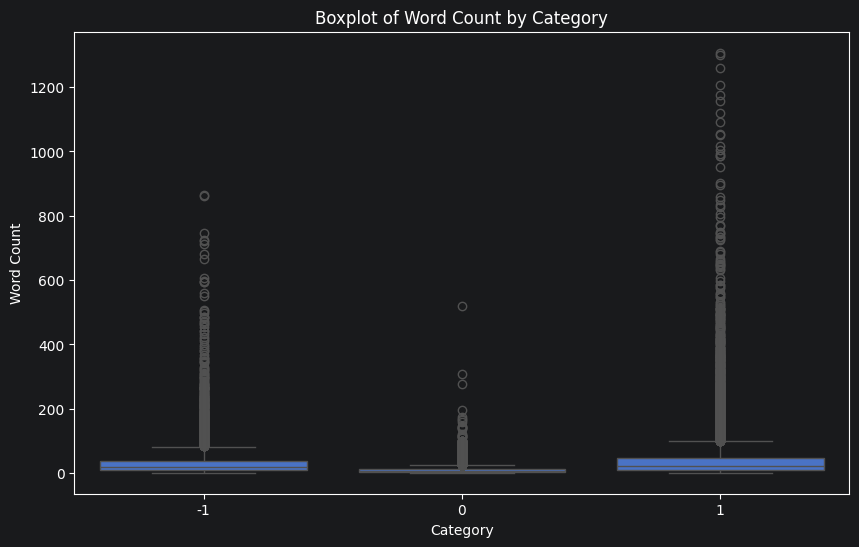

In [27]:
# create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Positive comments (category 1)**: The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.<br>
**Neutral comments (category 0)**: The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.<br>
**Negative comments (category -1)**: The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers.

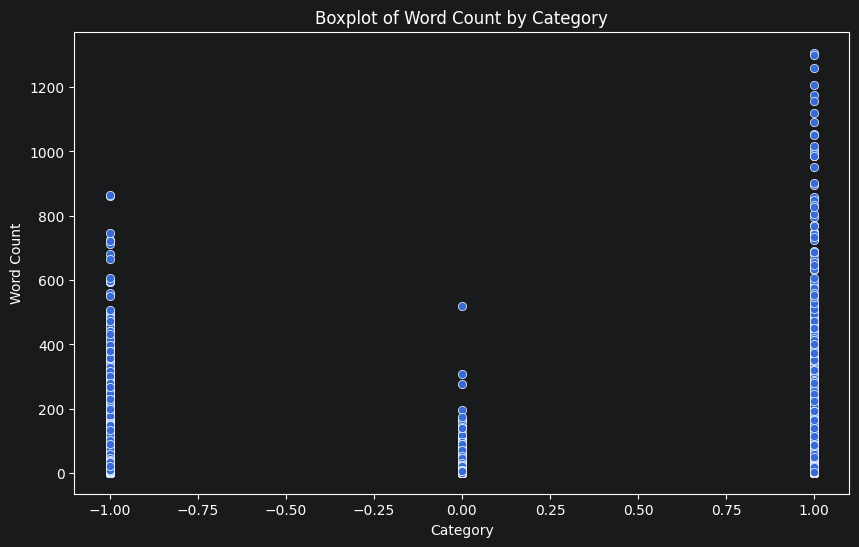

In [28]:
# create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

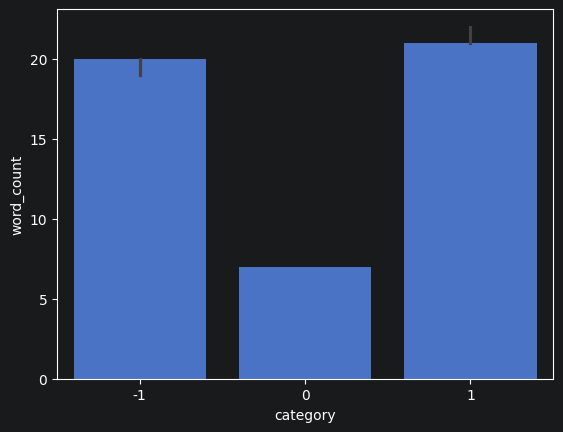

In [29]:
# median word counts among sentiments
sns.barplot(df,x='category',y='word_count',estimator='median')

<li>Seaborn’s error bars default to showing the uncertainty of your chosen estimator (the 95% confidence interval), not the min/max range of your raw data.
</li>
<li>Your scatterplot shows a massive, dense cluster of identical values at the very bottom for category 0.
</li>
<li>When Seaborn samples this data to calculate the median's confidence interval, almost every random sample yields that exact same bottom number.
</li>
<li>Because Seaborn is statistically certain the true median is that exact number, the error bar length is zero.</li>

In [30]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/breezy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
# English stopwords
stop_words = set(stopwords.words('english'))
# add teh english stop word column
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

In [32]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
13336,what gives you the idea that you will not meet...,-1,42,19
37229,chaliye delhi vanakkam,0,3,0
23155,toh phone yoga video bana lete,0,6,0
26661,shitbjpsays,0,1,0
6206,this fear mongering have many friends who are ...,1,82,26


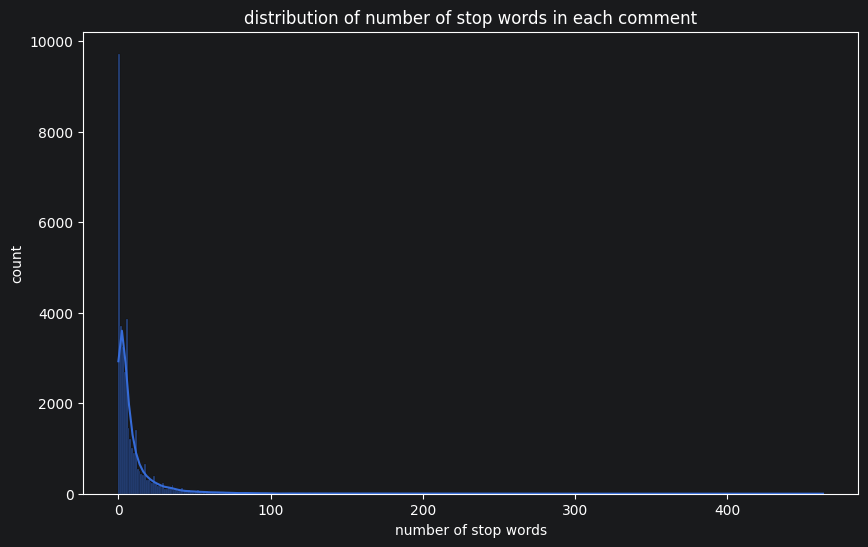

In [33]:
# create a distribution plot for view the "num_stop_words" column
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='num_stop_words',kde=True)
plt.title('distribution of number of stop words in each comment')
plt.xlabel('number of stop words')
plt.ylabel('count')
plt.show()

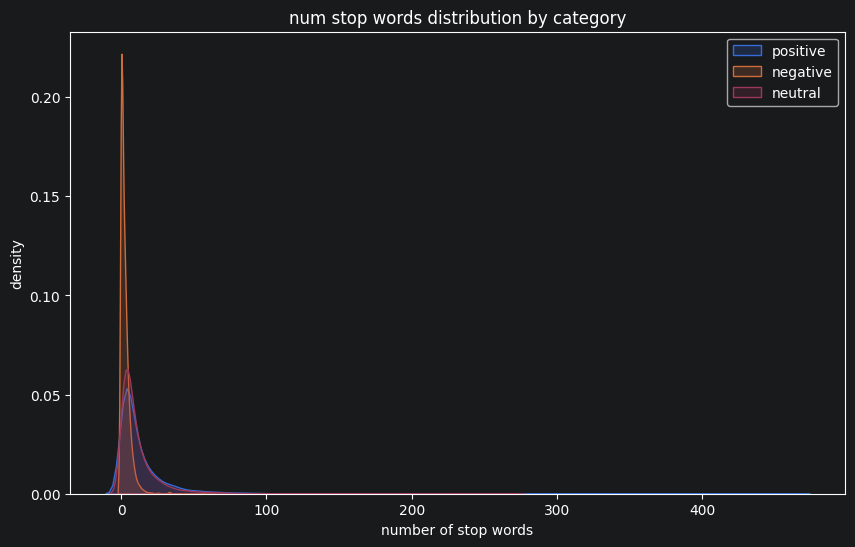

In [34]:
# create
plt.figure(figsize=(10,6))
sns.kdeplot(df[df["category"]==1]["num_stop_words"],label = "positive",fill=True,alpha = 0.2)
sns.kdeplot(df[df["category"]==0]["num_stop_words"],label = "negative",fill=True,alpha = 0.2)
sns.kdeplot(df[df["category"]==-1]["num_stop_words"],label = "neutral",fill=True,alpha = 0.2)

plt.title("num stop words distribution by category")
plt.xlabel("number of stop words")
plt.ylabel("density")
plt.legend()
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

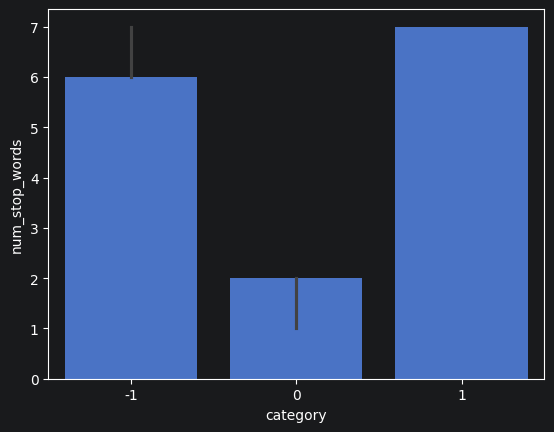

In [35]:
# check the median counts among the sentiments
sns.barplot(df,x='category',y='num_stop_words',estimator='median')

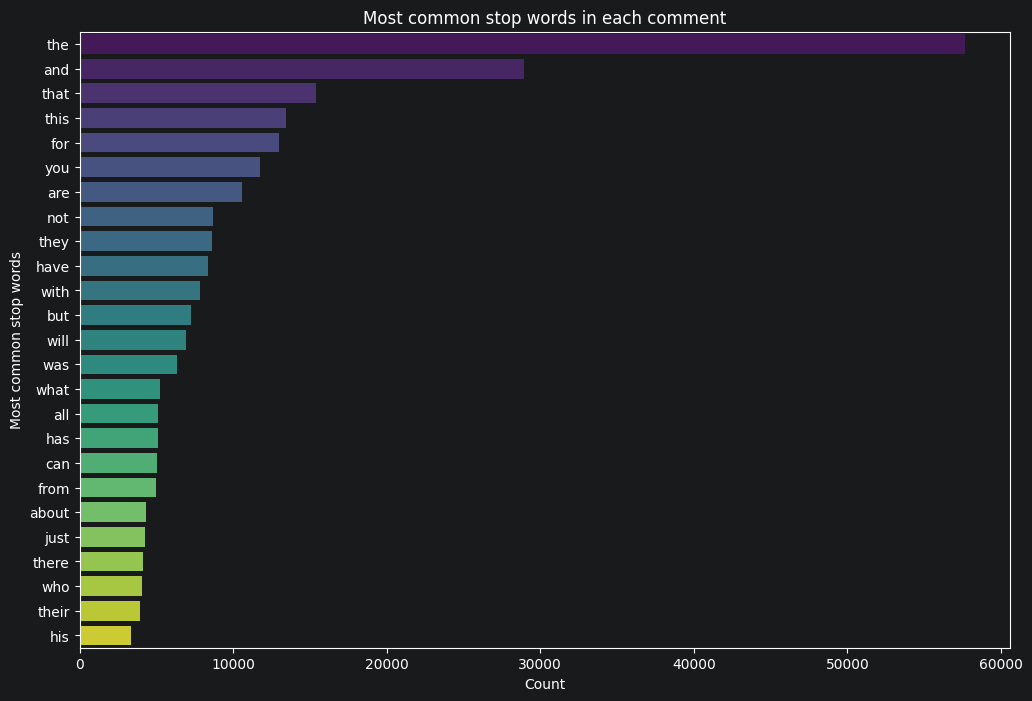

In [36]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

all_stop_words = [word for comment in df["clean_comment"] for word in comment.split() if word in stop_words]

most_common_stop_words = Counter(all_stop_words).most_common(25)
top_25_df = pd.DataFrame(most_common_stop_words, columns=['word','count'])

plt.figure(figsize=(12,8))
sns.barplot(data=top_25_df,x='count',y='word',palette='viridis',hue='word',legend=False)
plt.title('Most common stop words in each comment')
plt.ylabel('Most common stop words')
plt.xlabel('Count')
plt.show()

In [37]:
# add new column "num_chars" count of each char add to dataframe
df['num_chars'] = df['clean_comment'].apply(len)
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [38]:
# check the character
df['num_chars'].describe()

count    36793.000000
mean       181.852798
std        359.702163
min          1.000000
25%         38.000000
50%         80.000000
75%        184.000000
max       8664.000000
Name: num_chars, dtype: float64

In [39]:
from collections import Counter

# combine all comments into one large string and count the total count of the char
all_text = ' '.join(df['clean_comment'])
char_frequency = Counter(all_text)

char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)
char_frequency_df.tail()

,character,frequency
1345,唯,1
1346,统,1
1330,段,1
1331,她,1
1332,谁,1


In [40]:
# add new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
32732,what love about this exchange how goofy they a...,1,20,10,122,0
1160,“hum rajneeti mein nahin hain humara kaam ‘nam...,1,92,19,581,0
5789,yeah there one article also about how more peo...,1,73,34,424,0
24869,for some reason this just epic looking love th...,1,15,7,84,0
17182,next diwali will start working that company pl...,1,16,4,92,0


In [41]:
df['num_punctuation_chars'].describe()

count    36793.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: num_punctuation_chars, dtype: float64

In [42]:
# create def extract the top 25 bigrams/trigram

def get_top_ngrams(corpus, ngram_rng = None ,n=25):
    vec = CountVectorizer(ngram_range=(ngram_rng,ngram_rng), stop_words='english')
    x = vec.fit_transform(corpus)
    sum_words = np.asarray(x.sum(axis=0)).flatten()
    words_freq = [
        (word, sum_words[idx])
        for word, idx in vec.vocabulary_.items()
    ]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:n], columns=['ngram', 'count'])

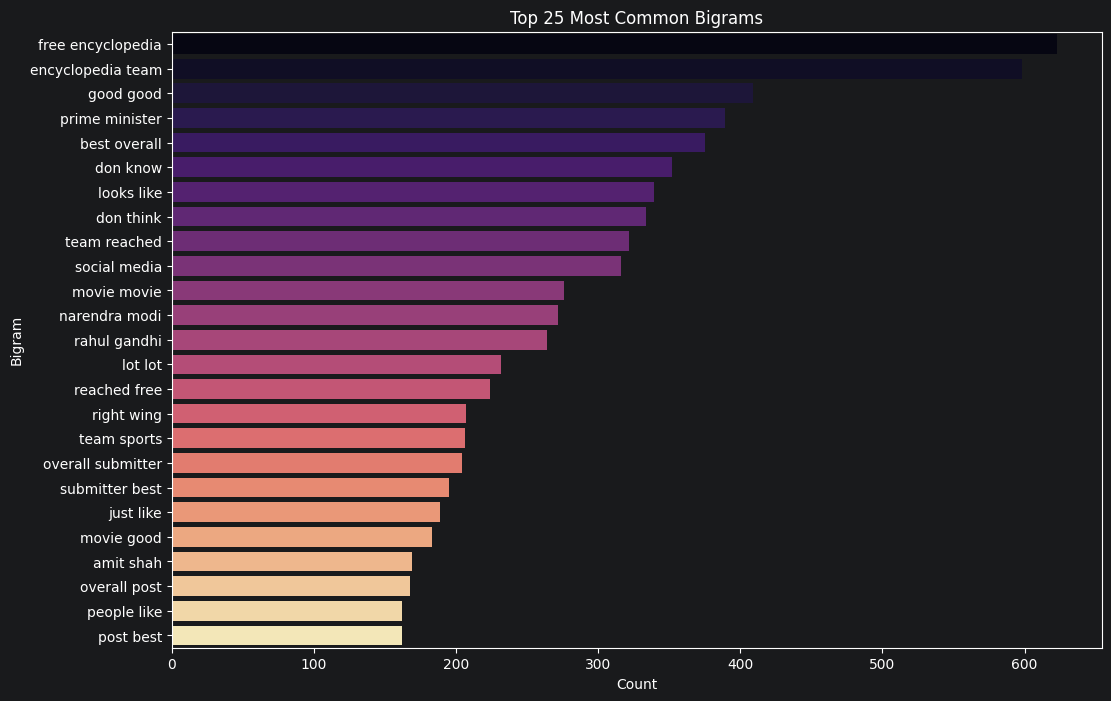

In [43]:
# the top 25 bigrams
top_25_bigrams_df = get_top_ngrams(df['clean_comment'], ngram_rng=2,n=25)

# plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='ngram', palette='magma',hue='ngram')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


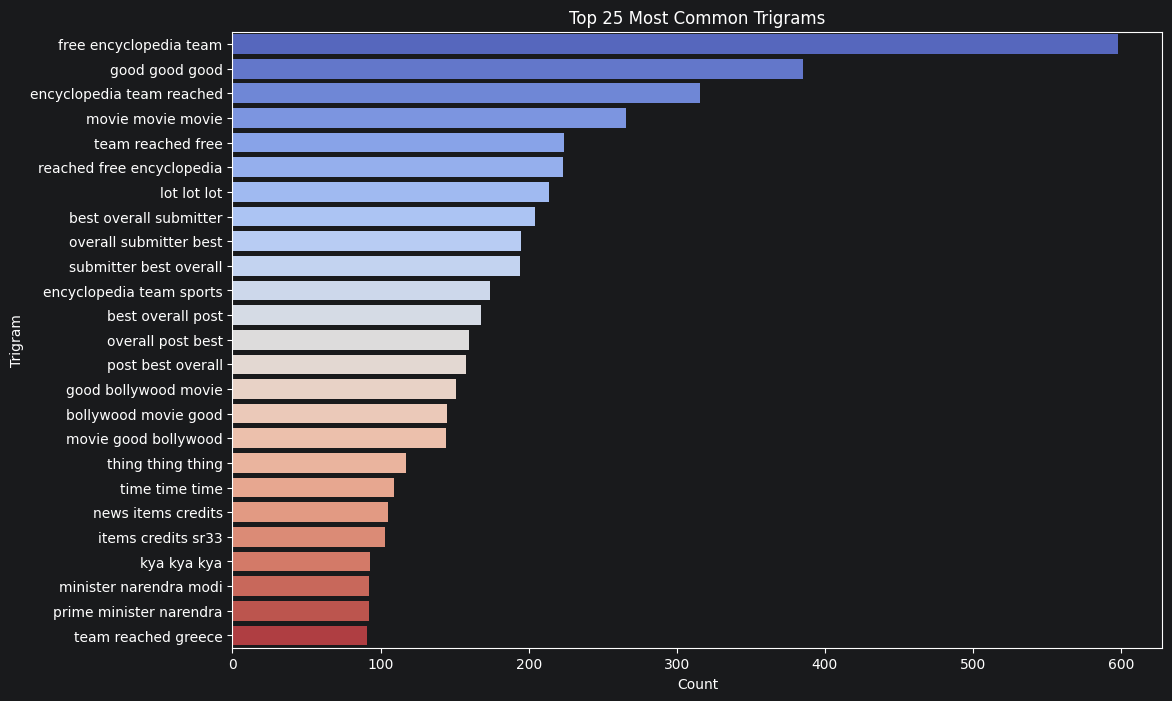

In [44]:
# the top 25 trigrams
top_25_trigrams_df = get_top_ngrams(df['clean_comment'], ngram_rng=3,n=25)

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='ngram', palette='coolwarm',hue='ngram')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [45]:
import regex as re


def filter_characters(text):
    if not isinstance(text, str):
        return text

    pattern = r'[^\x00-\x7F\p{Emoji}\p{Sc}]'

    # replace the unwanted characters with nothing (remove them)
    cleaned_text = re.sub(pattern, '', text)

    # clean up any extra spaces left behind by the removed characters
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

df['clean_comment'] = df['clean_comment'].apply(filter_characters)
df

,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0
...,...,...,...,...,...,...
37244,jesus,0,1,0,5,0
37245,kya bhai pure saal chutiya banaya modi aur jab...,1,19,0,99,0
37246,downvote karna tha par upvote hogaya,0,6,0,36,0
37247,haha nice,1,2,0,9,0


In [46]:
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
6,,1087303
12,e,666610
13,t,491287
1,a,481134
3,i,401388
...,...,...
64,☹,1
66,⛵,1
67,☠,1
68,⚰,1


In [47]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [48]:
from nltk.corpus import stopwords

# Define the set of words you want to KEEP in your text (remove from stopwords)
negation_words = {
    'no', 'nor', 'not', 'ain', 'aren', "aren't", 'couldn', "couldn't",
    'didn', "didn't", 'doesn', "doesn't", 'don', "don't", 'hadn', "hadn't",
    'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't",
    'wouldn', "wouldn't", 'but', 'against'
}

# Create the custom stopword set
without_neg_stopwords = set(stopwords.words('english')) - negation_words

# If you want it back as a list
custom_stopwords_list = list(without_neg_stopwords)
# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment_no_stopwords'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in without_neg_stopwords])
)

In [49]:
# lemmatize the wording
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

# apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment_no_stopwords_lemmatized'] = df['clean_comment_no_stopwords'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to /home/breezy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num_punctuation_chars,clean_comment_no_stopwords,clean_comment_no_stopwords_lemmatized
0,family mormon have never tried explain them th...,1,39,13,259,0,family mormon never tried explain still stare ...,family mormon never tried explain still stare ...
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0,buddhism much lot compatible christianity espe...,buddhism much lot compatible christianity espe...
2,seriously don say thing first all they won get...,-1,86,40,459,0,seriously don say thing first won get complex ...,seriously don say thing first won get complex ...
3,what you have learned yours and only yours wha...,0,29,15,167,0,learned want teach different focus goal not wr...,learned want teach different focus goal not wr...
4,for your own benefit you may want read living ...,1,112,45,690,0,benefit may want read living buddha living chr...,benefit may want read living buddha living chr...


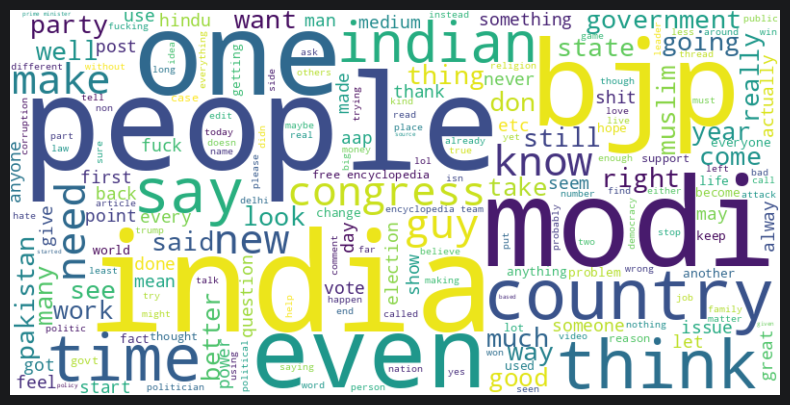

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment_no_stopwords_lemmatized'])

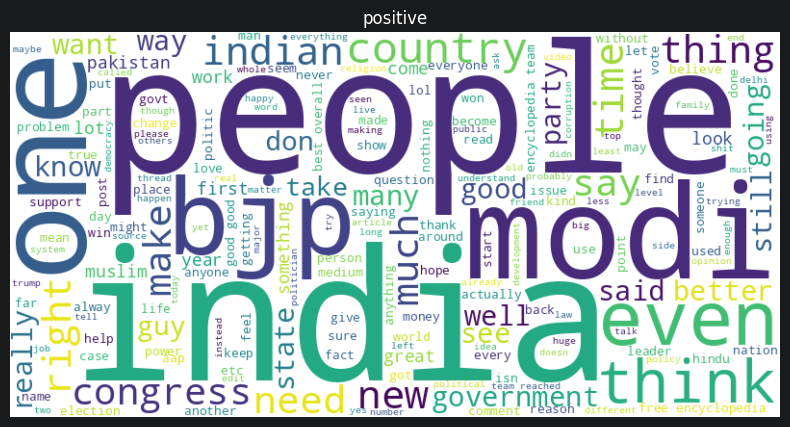

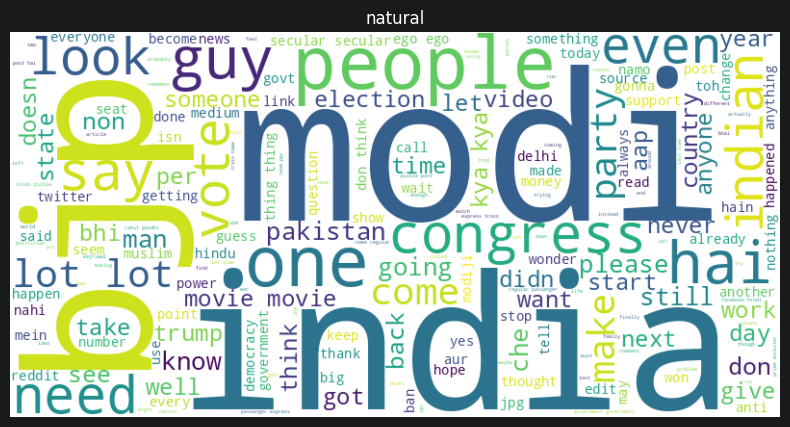

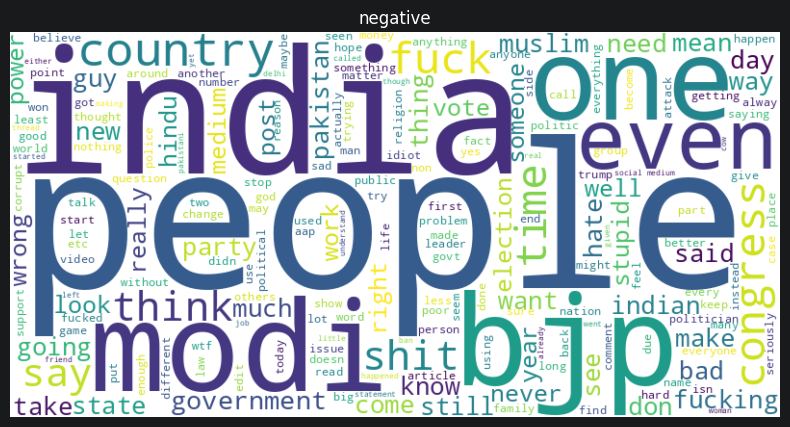

In [55]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text,title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_word_cloud(df[df['category'] == 1]['clean_comment_no_stopwords_lemmatized'],"positive")
plot_word_cloud(df[df['category'] == 0]['clean_comment_no_stopwords_lemmatized'],"natural")
plot_word_cloud(df[df['category'] == -1]['clean_comment_no_stopwords_lemmatized'],"negative")

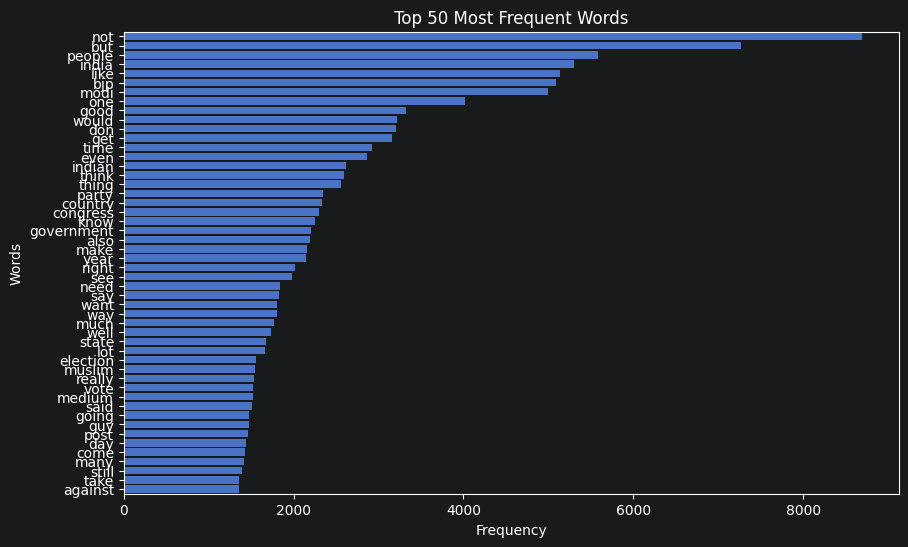

In [57]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # flatten all words in the content column
    words = ' '.join(df['clean_comment_no_stopwords_lemmatized']).split()

    counter = Counter(words)
    most_common_words = counter.most_common(n)


    words, counts = zip(*most_common_words)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

plot_top_n_words(df, n=50)


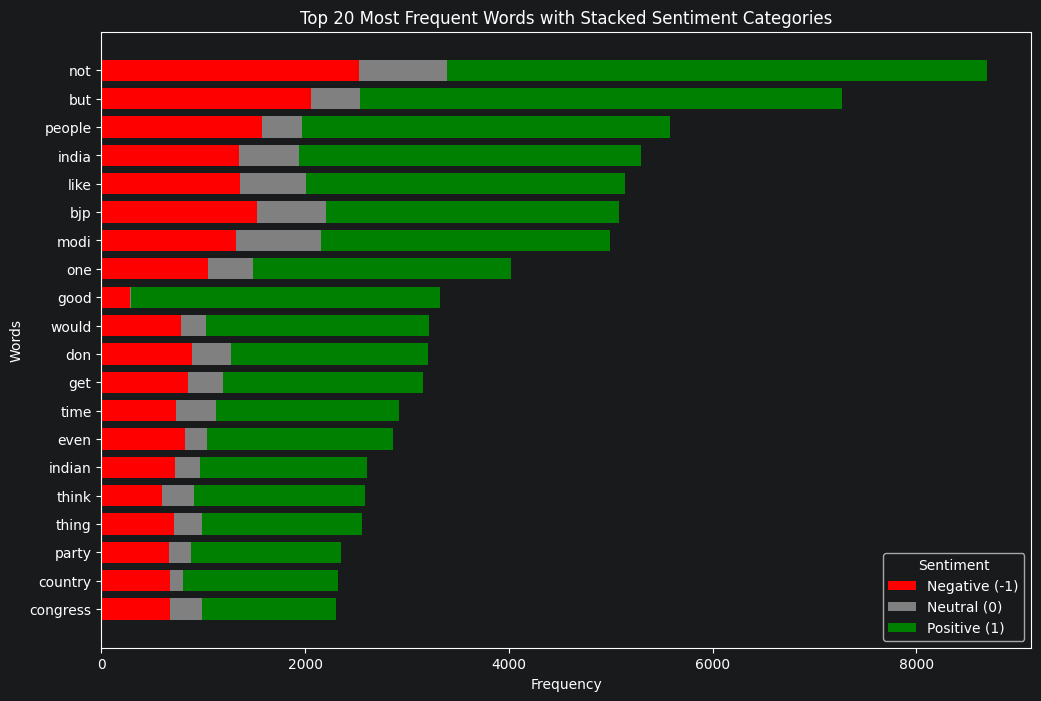

In [59]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment_no_stopwords_lemmatized'].split()
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()



plot_top_n_words_by_category(df, n=20)
